In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as c
from scipy.signal import fftconvolve
from q3dfit.q3din import q3din
from q3dfit.q3dout import q3dout, load_q3dout
from q3dfit.q3df import q3dfit
from q3dfit import q3dutil
from q3dfit.checkcomp import checkcomp
from q3dfit.q3dcollect import q3dcollect
from q3dfit.linelist import linelist

In [2]:
# global parameters
label = "4C1971_other_lines"
infile = "4C1971_G235H_NRS1_NRS2_s3d.fits"
outdir = "output"
redshift = 3.5892
# fitrange = [2.16, 2.375] #TODO: Create dictionary of fitranges for the other lines
ncores = 22

# infile_wo_cont = label+"_wo_continuum.fits"
# infile_converted_units = label+"_converted_units.fits"

indir = "input"
logdir = "logfiles"
if not os.path.exists(indir):
    os.makedirs(indir)

cols, rows = None, None
# lines to fit (name & wavelength)
# lines = ['Hbeta', '[OIII]4959', '[OIII]5007'] #TODO: Choose which other lines to fit + get 5007 as reference
# line_wavelengths = list(linelist(lines)["lines"]) # micron
# lines = ["[OIII]5007", "[OII]3726", "[OII]3729", "[NeIII]3869", "[NII]6548", "Halpha", "[NII]6583", "[SII]6716", "[SII]6731"]
#          ---OIII---    ---------OII----------    ---NeIII---    -------------Halpha-------------    ---------SII----------
lines = {"OII": ["[OII]3726", "[OII]3729"], 
         "OII2": ["[OII]3726"], 
         "NeIII": ["[NeIII]3869"], 
         "Halpha": ["Halpha", "[NII]6548", "[NII]6583"], 
         "SII": ["[SII]6716", "[SII]6731"]}
line_wavelengths = {key: list(linelist(value)["lines"]) for key, value in lines.items()}
o3_wavelength = list(linelist(["[OIII]5007"])["lines"])[0]
fitrange = {"OII": [1.67, 1.73], 
            "OII2": [1.67, 1.73],
            "NeIII": [1.74, 1.82], 
            "Halpha": [2.95, 3.06], 
            "SII": [3.04, 3.14]}
c_kms = c.c.to("km/s").value

In [3]:
dataread = np.load("4C1971_neighbour_method.line.red.npz", allow_pickle=True)
emlflx = dataread['emlflx'].item()
# emlflxerr = dataread['emlflxerr'].item()
emlncomp = dataread['emlncomp'].item()
emlsig = dataread['emlsig'].item()
# emlsigerr = dataread['emlsigerr'].item()
emlwav = dataread['emlwav'].item()
# emlwaverr = dataread['emlwaverr'].item()
# emlweq = dataread['emlweq'].item()
# ncols = dataread['ncols'].item()
# nrows = dataread['nrows'].item()

In [4]:
# def init_fit_other_lines(line_to_fit):
#     assert line_to_fit in lines.keys(), "invalid line"
#     # set up directories
#     outdir_n = outdir + "_" + line_to_fit
#     if not os.path.exists(outdir_n):
#         os.makedirs(outdir_n)
#     logdir_n = logdir + "_" + line_to_fit
#     if not os.path.exists(logdir_n):
#         os.makedirs(logdir_n)

#     logfile = os.path.join(logdir_n, label+"_"+line_to_fit+"-fitlog.txt")
#     q3di = q3din(infile, label+"_"+line_to_fit, outdir=outdir_n, logfile=logfile)
#     q3di.argsreadcube = {"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}
#     cube = q3di.load_cube()
#     q3di.name = label+"_"+line_to_fit
#     q3di.zsys_gas = redshift
#     q3di.fitrange = fitrange[line_to_fit]

#     # line fit
#     q3di.init_linefit(lines[line_to_fit], linetie=lines[line_to_fit][0], maxncomp=int(np.nanmax(emlncomp["[OIII]5007"])), checkcomp=False)
#     q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
#     q3di.siglim_gas = np.array([0., 1000.])
#     # q3di.argslineinit['flxlim'] = np.array([0., 1e-14]) / cube.fluxnorm
#     q3di.argslinefit['method'] = 'least_squares'
#     q3di.argslinefit['ftol'] = 1.e-8
#     q3di.argslinefit['gtol'] = 1.e-8
#     q3di.argslinefit['xtol'] = 1.e-8
#     q3di.argslinefit['x_scale'] = 'jac'
#     q3di.argslinefit['tr_solver'] = 'lsmr'

#     q3di.argscheckcomp['sigcut'] = 3.
#     # q3di.argscheckcomp['ignore']= ['Hbeta']
#     q3di.perror_useresid = True

#     q3di.snr = 3.0
#     q3di.snr_thresh = None

#     for line in lines[line_to_fit]:
#         for i in range(q3di.maxncomp):
#             q3di.zinit_gas[line][:,:,i] = emlwav[f"c{i+1}"]["[OIII]5007"] / o3_wavelength - 1
#             q3di.siginit_gas[line][:,:,i] = emlsig[f"c{i+1}"]["[OIII]5007"]
#         mask = ~np.isnan(q3di.zinit_gas[line])
#         reversed_mask = mask[:,:,::-1]
#         q3di.ncomp[line] = np.where(reversed_mask.any(axis=2), q3di.maxncomp - np.argmax(reversed_mask, axis=2), 0)
#         # q3di.ncomp[line] = np.where(np.isnan(emlncomp["[OIII]5007"]), 0, emlncomp["[OIII]5007"]).astype(int)
#         q3di.zinit_gas[line] = np.where(mask, q3di.zinit_gas[line], np.nanmean(q3di.zinit_gas[line], axis=2)[:,:,None])
#         q3di.siginit_gas[line][~mask] = 0.
#         q3di.linevary[line]['flx'][~mask] = False
#         q3di.linevary[line]['cwv'][:,:,:] = False
#         q3di.linevary[line]['sig'][:,:,:] = False

#     # continum fit
#     q3di.init_contfit("fitpoly")
#     q3di.argscontfit.update({"fitord": 1})
#     q3di.maskwidths_def = 1500
#     q3di.masksig_secondfit = 4

#     filename_q3di = os.path.join(indir, f"q3di_{label}_{line_to_fit}.npy")
#     q3di.filename = filename_q3di
#     np.save(filename_q3di, q3di)
#     return q3di

In [5]:
# cols, rows = np.where(emlncomp["[OIII]5007"] > 0)
# cols, rows = cols.tolist(), rows.tolist()
# line_to_fit = "OII2"
# q3di = init_fit_other_lines(line_to_fit)
# q3dfit(q3di.filename, cols, rows, onefit=True, quiet=True, ncores=ncores, nocrash=True)
# q3dcollect(q3di.filename, cols, rows, compsortpar=None, quiet=True)

In [6]:
# for line in lines[line_to_fit]:
#     q3di.ncomp[line] = np.where(np.isnan(emlncomp["[OIII]5007"]), 0, emlncomp["[OIII]5007"]).astype(int)
# np.save(q3di.filename, q3di)

In [7]:
# q3do = load_q3dout(q3di, 15, 40)
# q3do.plot_line(q3di, plotargs={"line": ["Halpha"], "nx": 1, "size": [0.05, 0.07], "figsize": (10,6)})
# for i in q3do.param:
#     if "sig" in i:
#         print(i, q3do.param[i])
# print("---")
# sig = np.load("output_Halpha/4C1971_other_lines_Halpha.line.npz", allow_pickle=True)["emlsig"].item()
# for i in range(5):
#     print(sig[f"c{i+1}"]["Halpha"][14,39])

In [8]:
def makedir(*dirs):
    for d in dirs:
        if not os.path.exists(d):
            os.makedirs(d)

In [21]:
binned = False
if binned:
    cols, rows = np.load("colsrows_2.npy")
    binned_map = np.load("binned_map_2.npy")
else:
    cols, rows = None, None

In [25]:
def init_fit_other_lines(
        infile: str, 
        label: str, 
        lines: list[str],
        outdir: str,
        redshift: float, 
        fitrange: list[float],
        dirlabel: str
        ) -> q3din:
    
    # set up directories
    indir = os.path.join(outdir, "input")
    outdir_n = os.path.join(outdir, f"output_{dirlabel}")
    logdir_n = os.path.join(outdir, f"logfiles_{dirlabel}")
    makedir(indir, outdir_n, logdir_n)

    logfile = os.path.join(logdir_n, label+"-fitlog.txt")
    q3di = q3din(infile, label, outdir=outdir_n, logfile=logfile)
    q3di.argsreadcube = {"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}
    cube = q3di.load_cube()
    q3di.name = label
    q3di.zsys_gas = redshift
    q3di.fitrange = fitrange

    # line fit
    q3di.init_linefit(lines, linetie=lines[0], maxncomp=int(np.nanmax(emlncomp["[OIII]5007"])), checkcomp=False)
    q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
    q3di.siglim_gas = np.array([0., 1000.])
    # q3di.argslineinit['flxlim'] = np.array([0., 1e-14]) / cube.fluxnorm
    q3di.argslinefit['method'] = 'least_squares'
    q3di.argslinefit['ftol'] = 1.e-8
    q3di.argslinefit['gtol'] = 1.e-8
    q3di.argslinefit['xtol'] = 1.e-8
    q3di.argslinefit['x_scale'] = 'jac'
    q3di.argslinefit['tr_solver'] = 'lsmr'

    q3di.argscheckcomp['sigcut'] = 3.
    # q3di.argscheckcomp['ignore']= ['Hbeta']
    q3di.perror_useresid = True

    q3di.snr = 3.0
    q3di.snr_thresh = None

    for line in lines:
        if binned:
            for c, r in zip(cols, rows):
                c1, r1 = c, r
                if all([np.isnan(emlwav[f"c{i+1}"]["[OIII]5007"][c, r]) for i in range(q3di.maxncomp)]):
                    # select initial condition from the bin
                    try:
                        idx = np.nanargmax(np.where(binned_map == binned_map[c, r], emlncomp["[OIII]5007"], np.nan))
                        c1, r1 = np.unravel_index(idx, binned_map.shape)
                    except ValueError:
                        ...
                for i in range(q3di.maxncomp):
                    q3di.zinit_gas[line][c, r, i] = emlwav[f"c{i+1}"]["[OIII]5007"][c1, r1] / o3_wavelength - 1
                    q3di.siginit_gas[line][c, r, i] = emlsig[f"c{i+1}"]["[OIII]5007"][c1, r1]
        else:
            for i in range(q3di.maxncomp):
                q3di.zinit_gas[line][:,:,i] = emlwav[f"c{i+1}"]["[OIII]5007"] / o3_wavelength - 1
                q3di.siginit_gas[line][:,:,i] = emlsig[f"c{i+1}"]["[OIII]5007"]
        
        mask = ~np.isnan(q3di.zinit_gas[line])
        reversed_mask = mask[:,:,::-1]
        q3di.ncomp[line] = np.where(reversed_mask.any(axis=2), q3di.maxncomp - np.argmax(reversed_mask, axis=2), 0)
        # q3di.ncomp[line] = np.where(np.isnan(emlncomp["[OIII]5007"]), 0, emlncomp["[OIII]5007"]).astype(int)
        q3di.zinit_gas[line] = np.where(mask, q3di.zinit_gas[line], np.nanmean(q3di.zinit_gas[line], axis=2)[:,:,None])
        q3di.siginit_gas[line][~mask] = 0.
        q3di.linevary[line]['flx'][~mask] = False
        q3di.linevary[line]['cwv'][:,:,:] = False
        q3di.linevary[line]['sig'][:,:,:] = False

    # continum fit
    q3di.init_contfit("fitpoly")
    q3di.argscontfit.update({"fitord": 1})
    q3di.maskwidths_def = 1500
    q3di.masksig_secondfit = 4

    filename_q3di = os.path.join(indir, f"q3di_{label}_{dirlabel}.npy")
    q3di.filename = filename_q3di
    np.save(filename_q3di, q3di)
    return q3di

In [26]:
if binned:
    plt.imshow(binned_map.T, origin="lower")
    idx = np.nanargmax(np.where(binned_map == binned_map[20, 50], emlncomp["[OIII]5007"], np.nan))
    np.unravel_index(idx, binned_map.shape)

In [27]:
Halpha_data = {
    "infile": "4C1971_binned_2.fits",
    "label": "4C1971",
    "lines": ["Halpha", "[NII]6548", "[NII]6583"],
    "outdir": "Halpha",
    "redshift": 3.5892,
    "fitrange": [2.95, 3.06],
    "dirlabel": "from_OIII_binned_2"
}
Halpha_data_not_binned = {
    "infile": "4C1971_G235H_NRS1_NRS2_s3d.fits",
    "label": "4C1971",
    "lines": ["Halpha", "[NII]6548", "[NII]6583"],
    "outdir": "Halpha",
    "redshift": 3.5892,
    "fitrange": [2.95, 3.06],
    "dirlabel": "from_OIII"
}
OIII_data = {
    "infile": "4C1971_binned_2.fits",
    "label": "4C1971",
    "lines": ["[OIII]5007", "[OIII]4959", "Hbeta"],
    "outdir": "OIII",
    "redshift": 3.5892,
    "fitrange": [2.16, 2.375],
    "dirlabel": "from_OIII_binned_2"
}
SII_data = {
    "infile": "4C1971_binned_2.fits",
    "label": "4C1971",
    "lines": ["[SII]6716", "[SII]6731"],
    "outdir": "SII",
    "redshift": 3.5892,
    "fitrange": [3.04, 3.14],
    "dirlabel": "from_OIII_binned_2"
}
NeIII_data = {
    "infile": "4C1971_binned_2.fits",
    "label": "4C1971",
    "lines": ["[NeIII]3869"],
    "outdir": "NeIII",
    "redshift": 3.5892,
    "fitrange": [1.74, 1.82],
    "dirlabel": "from_OIII_binned_2"
}
OII_data = {
    "infile": "4C1971_binned_2.fits",
    "label": "4C1971",
    "lines": ["[OII]3726", "[OII]3729"],
    "outdir": "OII",
    "redshift": 3.5892,
    "fitrange": [1.67, 1.73],
    "dirlabel": "from_OIII_binned_2"
}
OI_data = {
    "infile": "4C1971_binned_2.fits",
    "label": "4C1971",
    "lines": ["[OI]6300", "[OI]6364"],
    "outdir": "OI",
    "redshift": 3.5892,
    "fitrange": [2.85, 2.95],
    "dirlabel": "from_OIII_binned_2"
}
line_data = Halpha_data_not_binned
# line_data = Halpha_data
# line_data = OIII_data
# line_data = SII_data
# line_data = NeIII_data
# line_data = OII_data
# line_data = OI_data
q3di = init_fit_other_lines(**line_data)

Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: MJy/sr
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.


In [28]:
if cols is not None:
    cols_, rows_ = cols.tolist(), rows.tolist()
else: 
    cols_, rows_ = None, None
q3dfit(q3di.filename, cols_, rows_, onefit=True, quiet=True, ncores=ncores, nocrash=True)
q3dcollect(q3di.filename, cols_, rows_, compsortpar=None, quiet=True)
# for line in lines[line_to_fit]:
#     q3di.ncomp[line] = np.where(np.isnan(emlncomp["[OIII]5007"]), 0, emlncomp["[OIII]5007"]).astype(int)
# np.save(q3di.filename, q3di)

Core 15: # spaxels fit=264
Core 22: # spaxels fit=265
Core 16: # spaxels fit=264
Core 10: # spaxels fit=264
Core 12: # spaxels fit=264
Core 4: # spaxels fit=264
Core 21: # spaxels fit=264
Core 5: # spaxels fit=264
Core 7: # spaxels fit=264
Core 19: # spaxels fit=264
Core 11: # spaxels fit=265
Core 20: # spaxels fit=264
Core 17: # spaxels fit=264
Core 3: # spaxels fit=264
Core 8: # spaxels fit=264
Core 6: # spaxels fit=264
Core 14: # spaxels fit=264
Core 1: # spaxels fit=264
Core 18: # spaxels fit=264
Core 13: # spaxels fit=264
Core 9: # spaxels fit=264
Core 2: # spaxels fit=264
Not sorting components
        No data for [1, 1]
        No data for [1, 2]
        No data for [1, 3]
        No data for [1, 4]
        No data for [1, 5]
        No data for [1, 6]
        No data for [1, 75]
        No data for [1, 76]
        No data for [1, 77]
        No data for [1, 78]
        No data for [1, 79]
        No data for [1, 80]
        No data for [1, 81]
        No data for [1, 82]
      

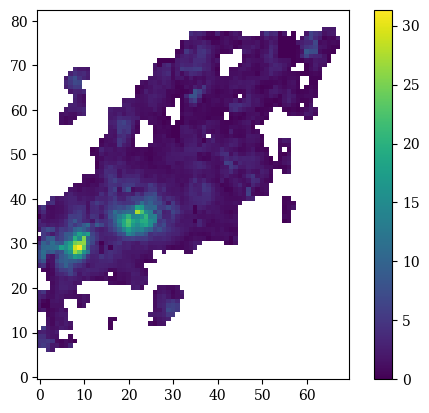

In [29]:
# dataread = np.load("Halpha/output_from_OIII_binned/4C1971.line.npz", allow_pickle=True)
dataread = np.load(f"{line_data["outdir"]}/output_{line_data["dirlabel"]}/{line_data["label"]}.line.npz", allow_pickle=True)
emlflx = dataread['emlflx'].item()
emlflxerr = dataread['emlflxerr'].item()
snr = emlflx["ftot"][line_data["lines"][0]]/emlflxerr["ftot"][line_data["lines"][0]]
plt.imshow(snr.T, origin="lower")
plt.colorbar()

In [32]:
import tkinter as tk
from q3dinterface import Q3DInterface
window = tk.Tk()
Q3DInterface(window, f"{line_data["label"]}_{line_data["dirlabel"]}", True, line_data["outdir"], snr.T)
def on_closing():
    window.quit()
    window.destroy()
window.protocol("WM_DELETE_WINDOW", on_closing)
window.mainloop()

<Figure size 640x480 with 0 Axes>

In [31]:
# from itertools import combinations
# for r in range(1, 3+1):
#     for c in combinations(range(5),r):
        
#         q3di = init_fit_other_lines_combination(c, **Halpha_data)